## EDA After Cleaning

In [14]:
%matplotlib inline

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for statistic analysis
from scipy import stats

In [16]:
# importing the complete dataset
df_zihum = pd.read_csv(r"H:\27 project\cleaning\cleaning_outputs\02_cleaned_data\df_zihum_clean.csv")
df = df_zihum.copy()


C:\Users\mtal\AppData\Local\Temp\3\ipykernel_1676\1854583669.py:2: DtypeWarning: Columns (38,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_zihum = pd.read_csv(r"H:\27 project\cleaning\cleaning_outputs\02_cleaned_data\df_zihum_clean.csv")


### 1- Missing Values

In [17]:
missing = (pd.DataFrame({
            "missing_count": df.isnull().sum(),
            "missing_percent": df.isnull().mean() * 100
            }).query("missing_count > 0").sort_values("missing_percent", ascending=False)
        )


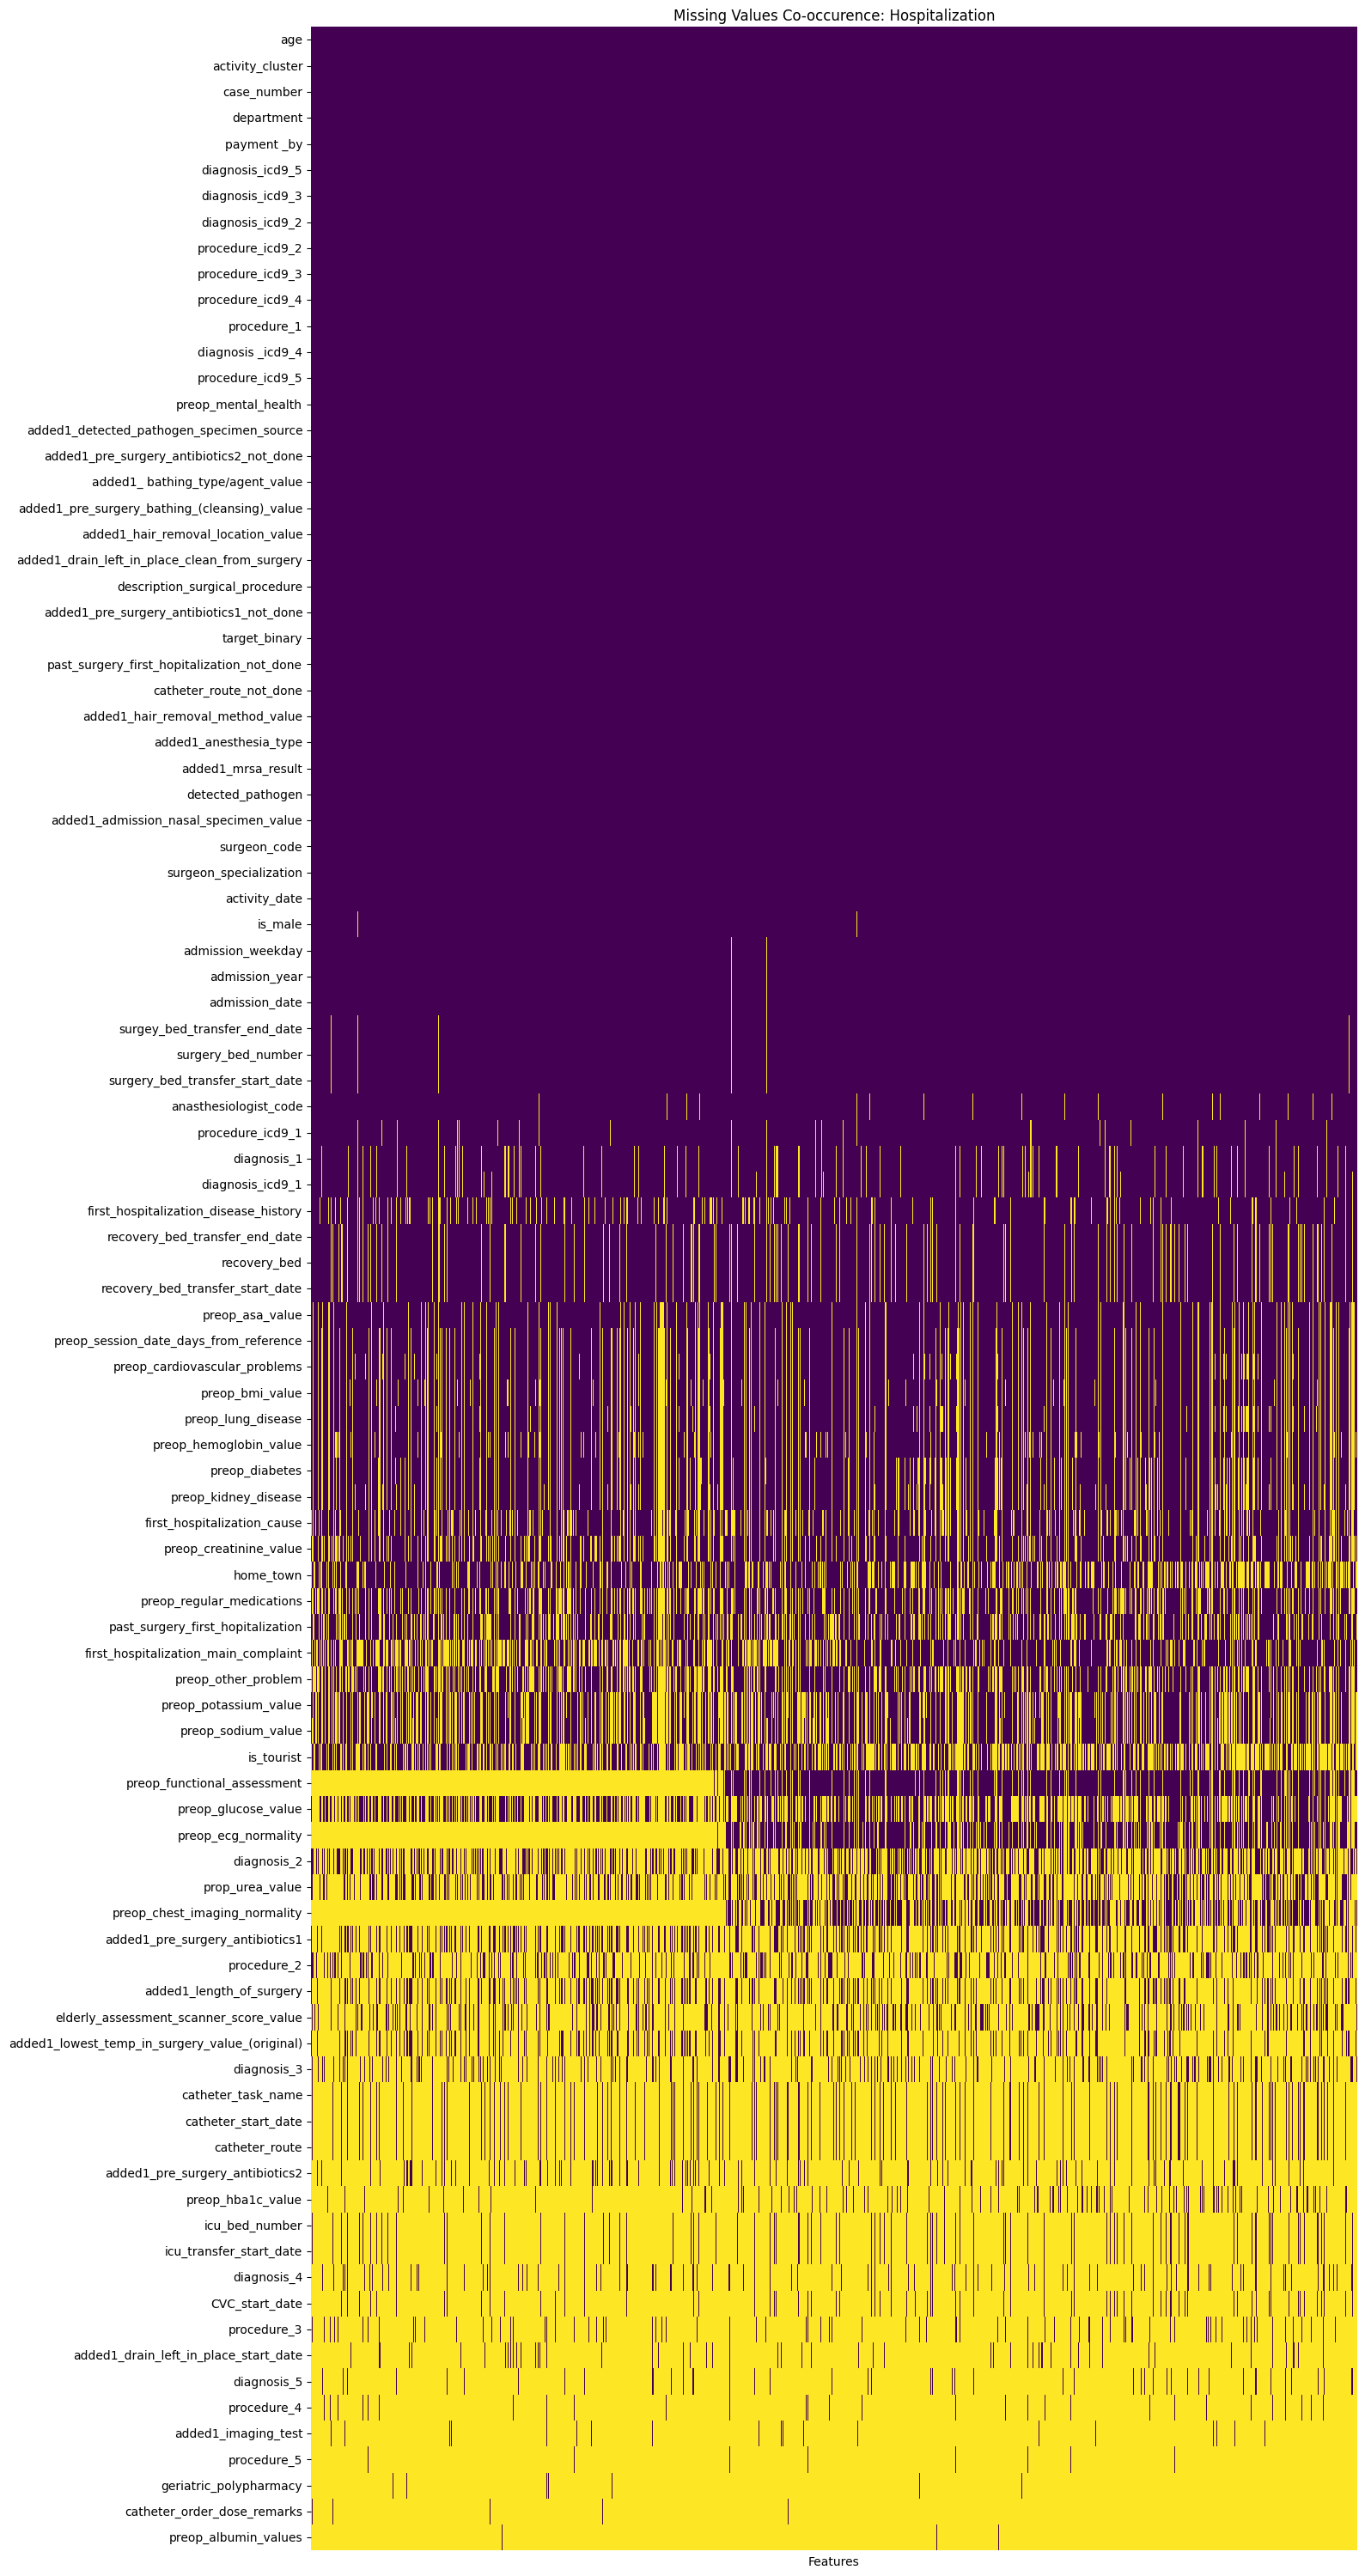

In [18]:
# Heatmap of the missing values
# Define the heatmap function
def plot_targeted_heatmap(data, column_list, title):
    """ Creates a missing values heatmap for a specific list of columns."""
    fig, ax = plt.subplots(figsize=(16, max(3, len(column_list) * 0.3 + 1)))
    sorted_cols = data[column_list].isnull().sum().sort_values().index.tolist()
    missing_matrix = data[sorted_cols].isnull().astype(int).T
    sns.heatmap(missing_matrix,
            cbar=False, 
            cmap = "viridis",
            vmin=0,
            vmax=1,
            xticklabels=False, 
            yticklabels=sorted_cols,
            ax=ax,
            rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("Features")
    plt.tight_layout()
    plt.show()

plot_targeted_heatmap(df, df.columns, "Missing Values Co-occurence: Hospitalization")


### 2- Distributions

In [19]:
# helper function for visualizations:
import bidi.algorithm as bidi
SECTION_WIDTH = 70

def section(title):
    """print a clearly visible section header."""
    print("\n" + "=" * SECTION_WIDTH)
    print(f"  {title}")
    print("=" * SECTION_WIDTH)


def fix_rtl(text):
    """reverse Hebrew text for correct matplotlib display"""
    try:
        return bidi.get_display(text)
    except:
        return text 

def make_grid(n_items, n_cols=4, col_w=6, row_h=5):
    """
    Create a subplot grid that fiys n_items_panels.
    - Caps columns at n_items so we never crate empty columns on a single row.
    - Returns (fig, axes_flat): axes is always a 1-D array for easy indexing.
    """
    n_cols = min(n_cols,n_items)
    n_rows = int(np.ceil(n_items / n_cols))
    fig,axes = plt.subplots(n_rows, n_cols,
                        figsize = (col_w * n_cols, row_h * n_rows))
    return fig, np.array(axes).flatten()


def hide_unused (axes,last_idx):
    """ Hide subplot panels that were not filled."""
    for j in range(last_idx + 1, len(axes)):
        axes[j].set_visible(False)

def plot_bar_grid(df, cols, title, n_cols=4, col_w=6, row_h=4, top_n=15, hspace=0.9, max_label_len=30, orientation="vertical"):
    """
    Draw a bar chart for each column in cols (value_counts, top top_n).
    Used for both categorical and boolean univariate plots.
    """
    if not cols:
        return
    fig,axes = make_grid(len(cols), n_cols=n_cols, col_w=col_w, row_h=row_h)
    for i, col in enumerate(cols):
        vc = df[col].value_counts(dropna=False).head(top_n)
        plot_kind = "bar" if orientation == "vertical" else  "barh"
        vc.plot(kind=plot_kind, ax=axes[i], color="steelblue", edgecolor="white")
        
        # truncate long value labels so they dont overlap each other
        short_labels = [fix_rtl(str(v)[:max_label_len] + ("..." if len(str(v)) > max_label_len else ""))
                        for v in vc.index] 
        if orientation == "vertical":
            axes[i].set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
        else:
            axes[i].set_yticklabels(short_labels, fontsize=8)
            axes[i].invert_yaxis()
        col_title = fix_rtl(col[:40] + "..." if len(col) > 40 else col)
        axes[i].set_title(f"{fix_rtl(col_title)}\nunique: {df[col].nunique()})", fontsize=10)
        axes[i].set_xlabel("")
        axes[i].set_position([
            axes[i].get_position().x0,
            axes[i].get_position().y0 + 0.01,
            axes[i].get_position().width,
            axes[i].get_position().height
        ])
    hide_unused(axes,i)
    plt.suptitle(title, fontsize=13)
    plt.subplots_adjust(hspace=1.5, left=0.05,right=0.98, top=0.93, bottom=0.05)
    plt.show()


#### Numeric columns

In [20]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ("target_binary", "case_number")]

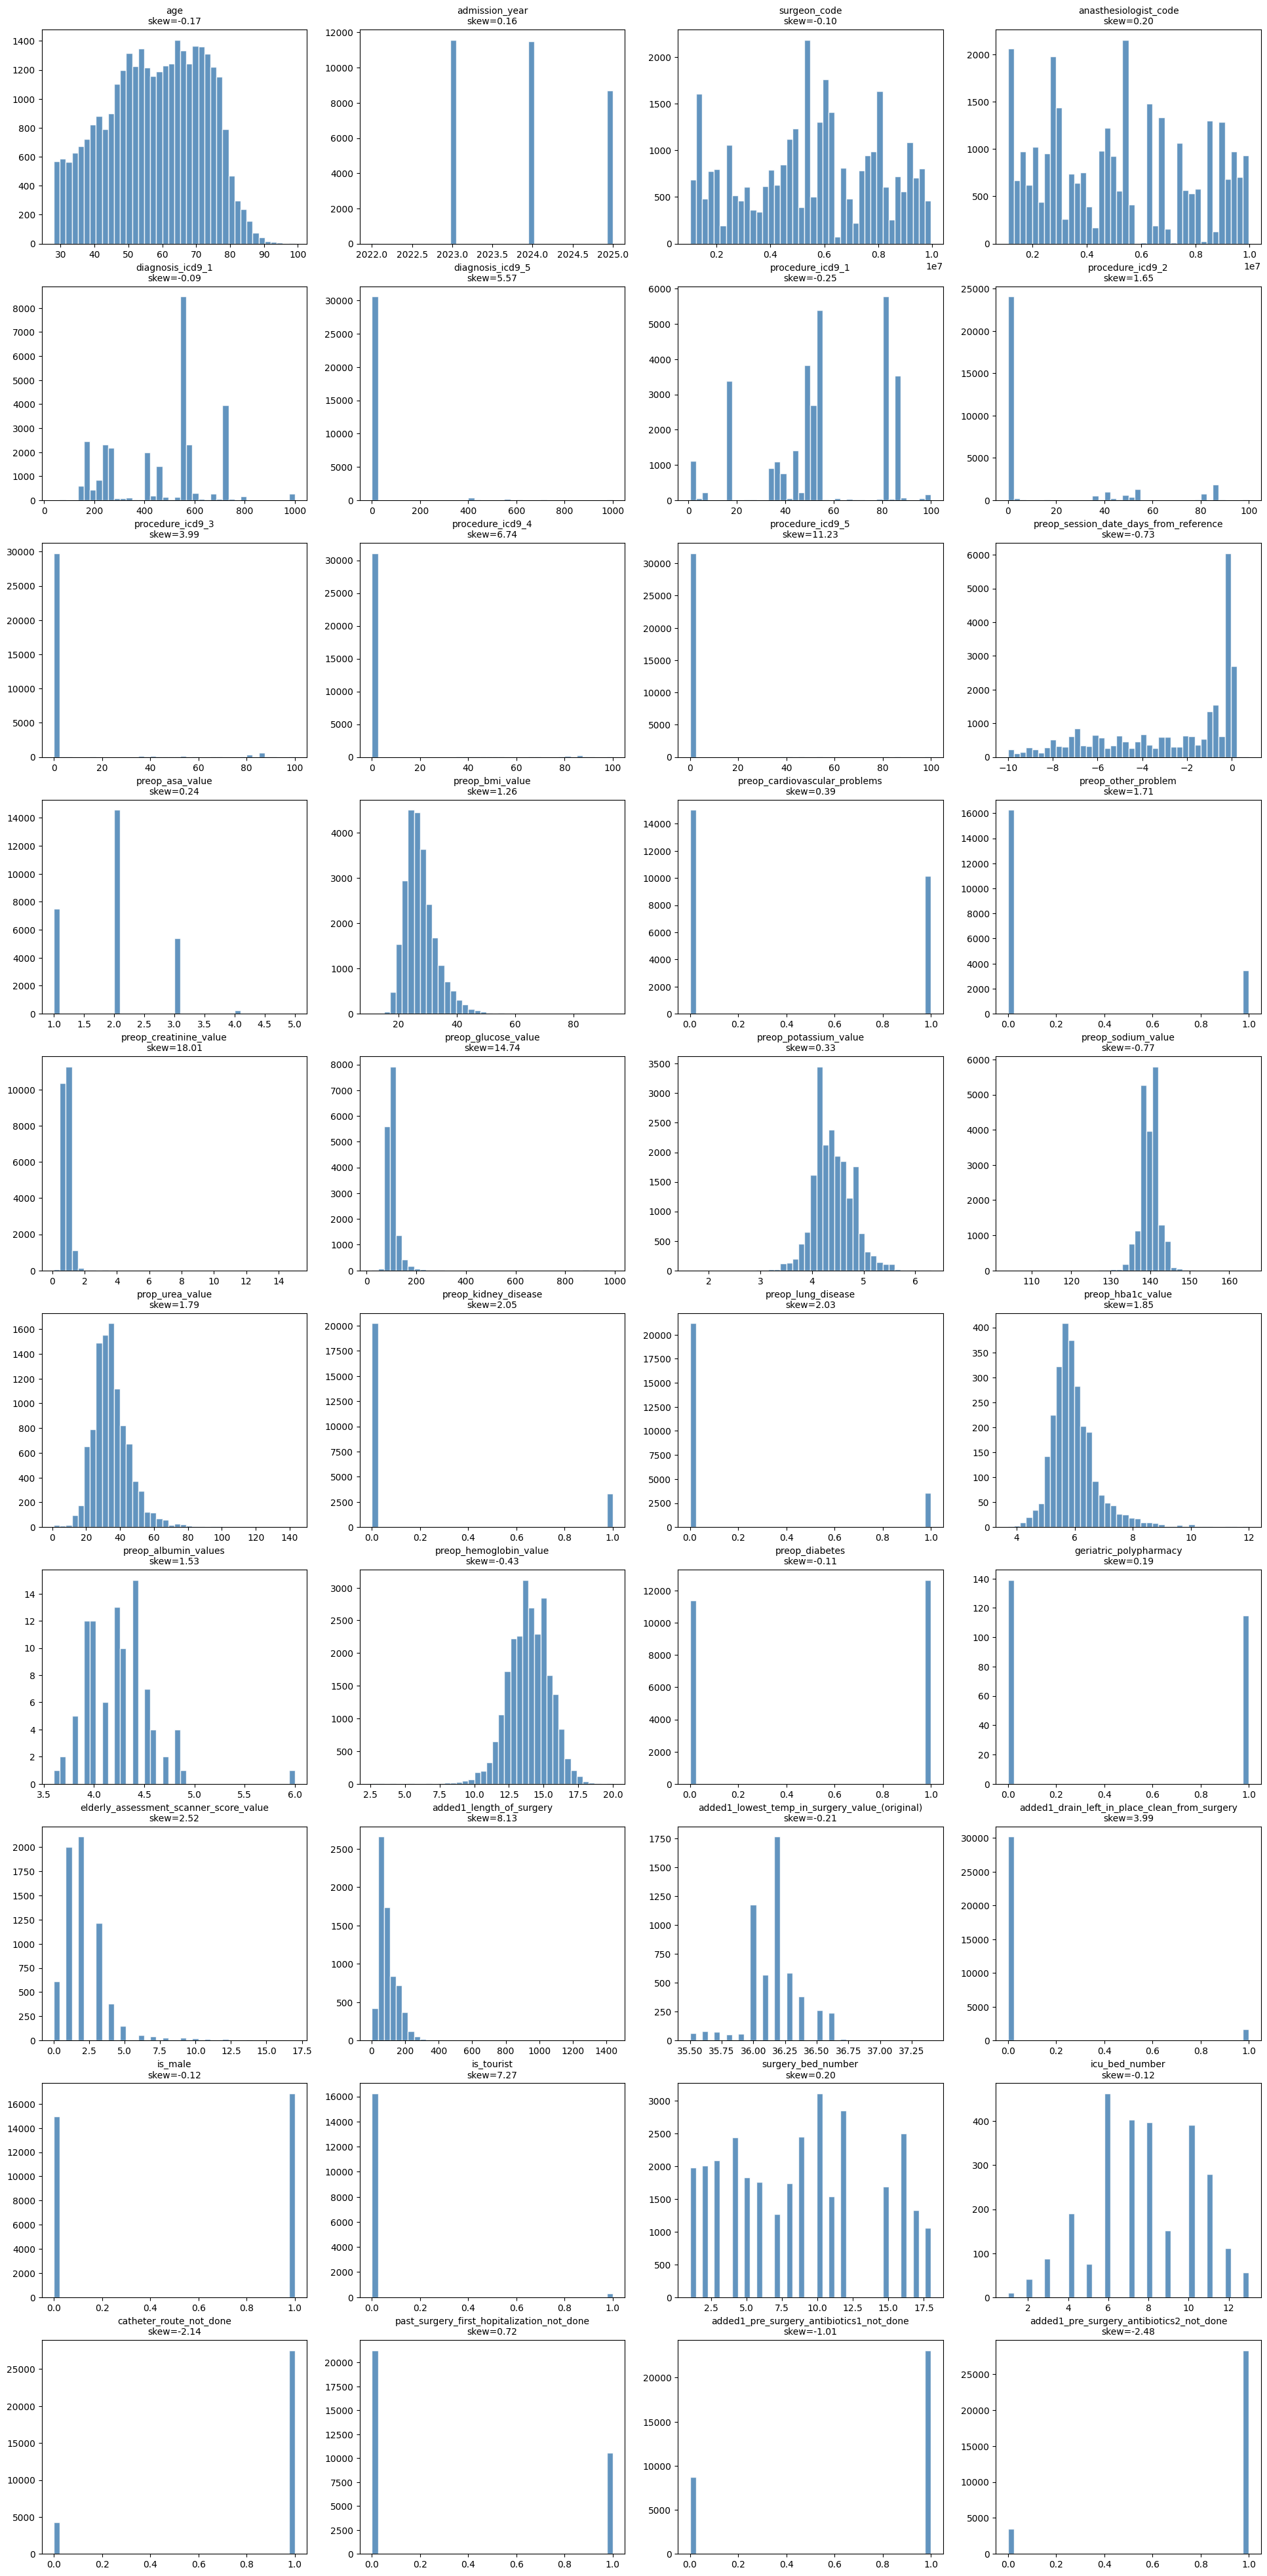

In [21]:
# Histogram per numeric column 
fig,axes = make_grid(len(numeric_cols), n_cols=4,col_w=6, row_h=5)

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    if data.empty:
            ax.set_title(f"{col}\nNo available data", fontsize=10)
            ax.axis("off")
            continue
    ax.hist(data,
            bins=40,
            edgecolor="white",
            color="steelblue",
            alpha=0.85)
    
    ax.set_title(f"{col}\nskew={data.skew():.2f}", fontsize=10)
    
hide_unused(axes,i)


#### Categorical columns

In [22]:
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

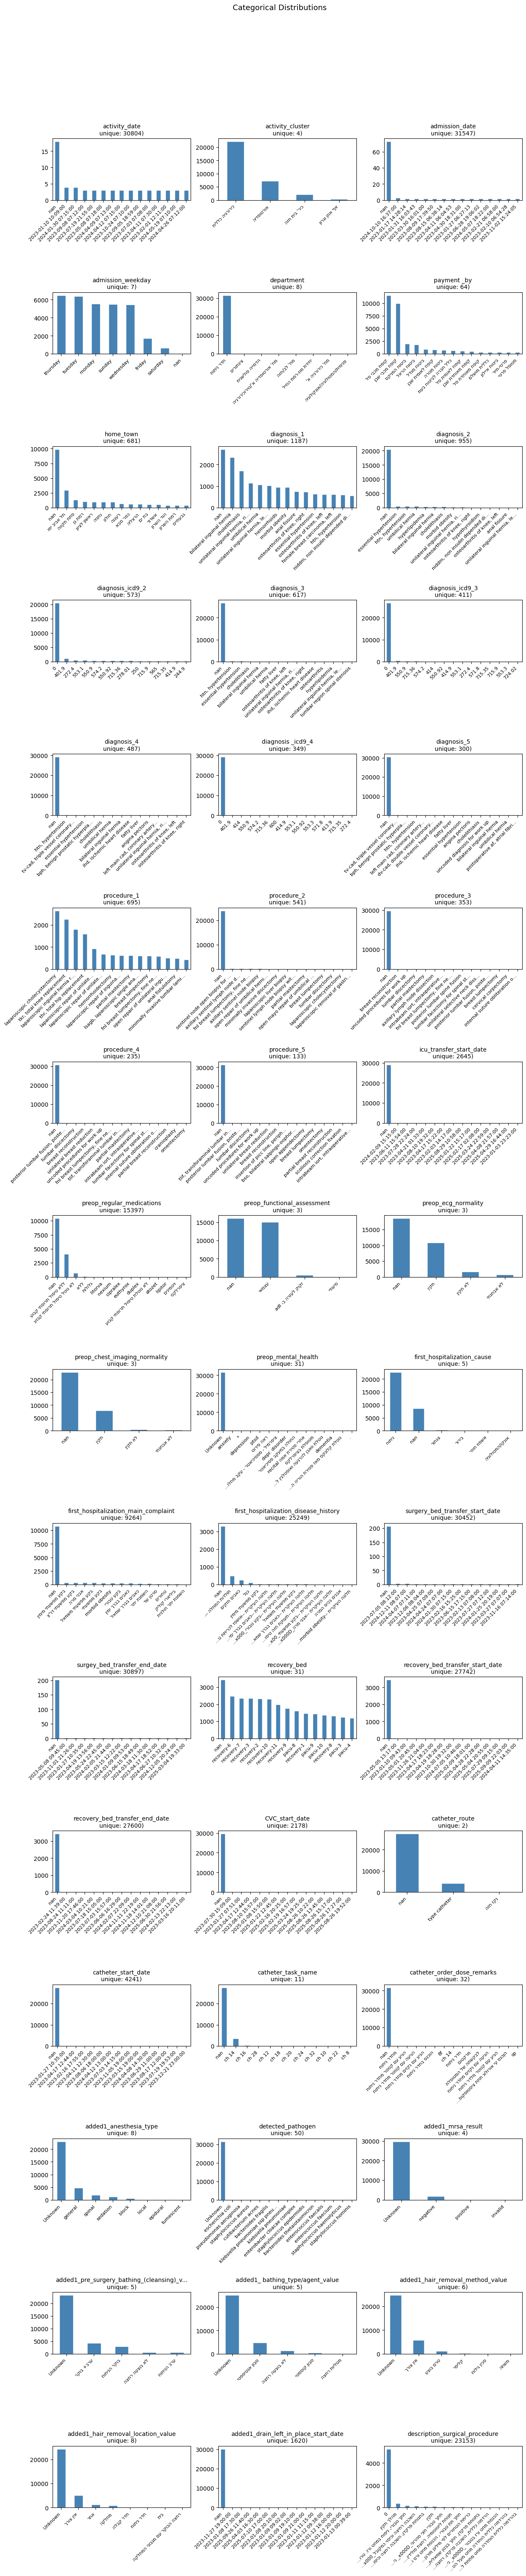

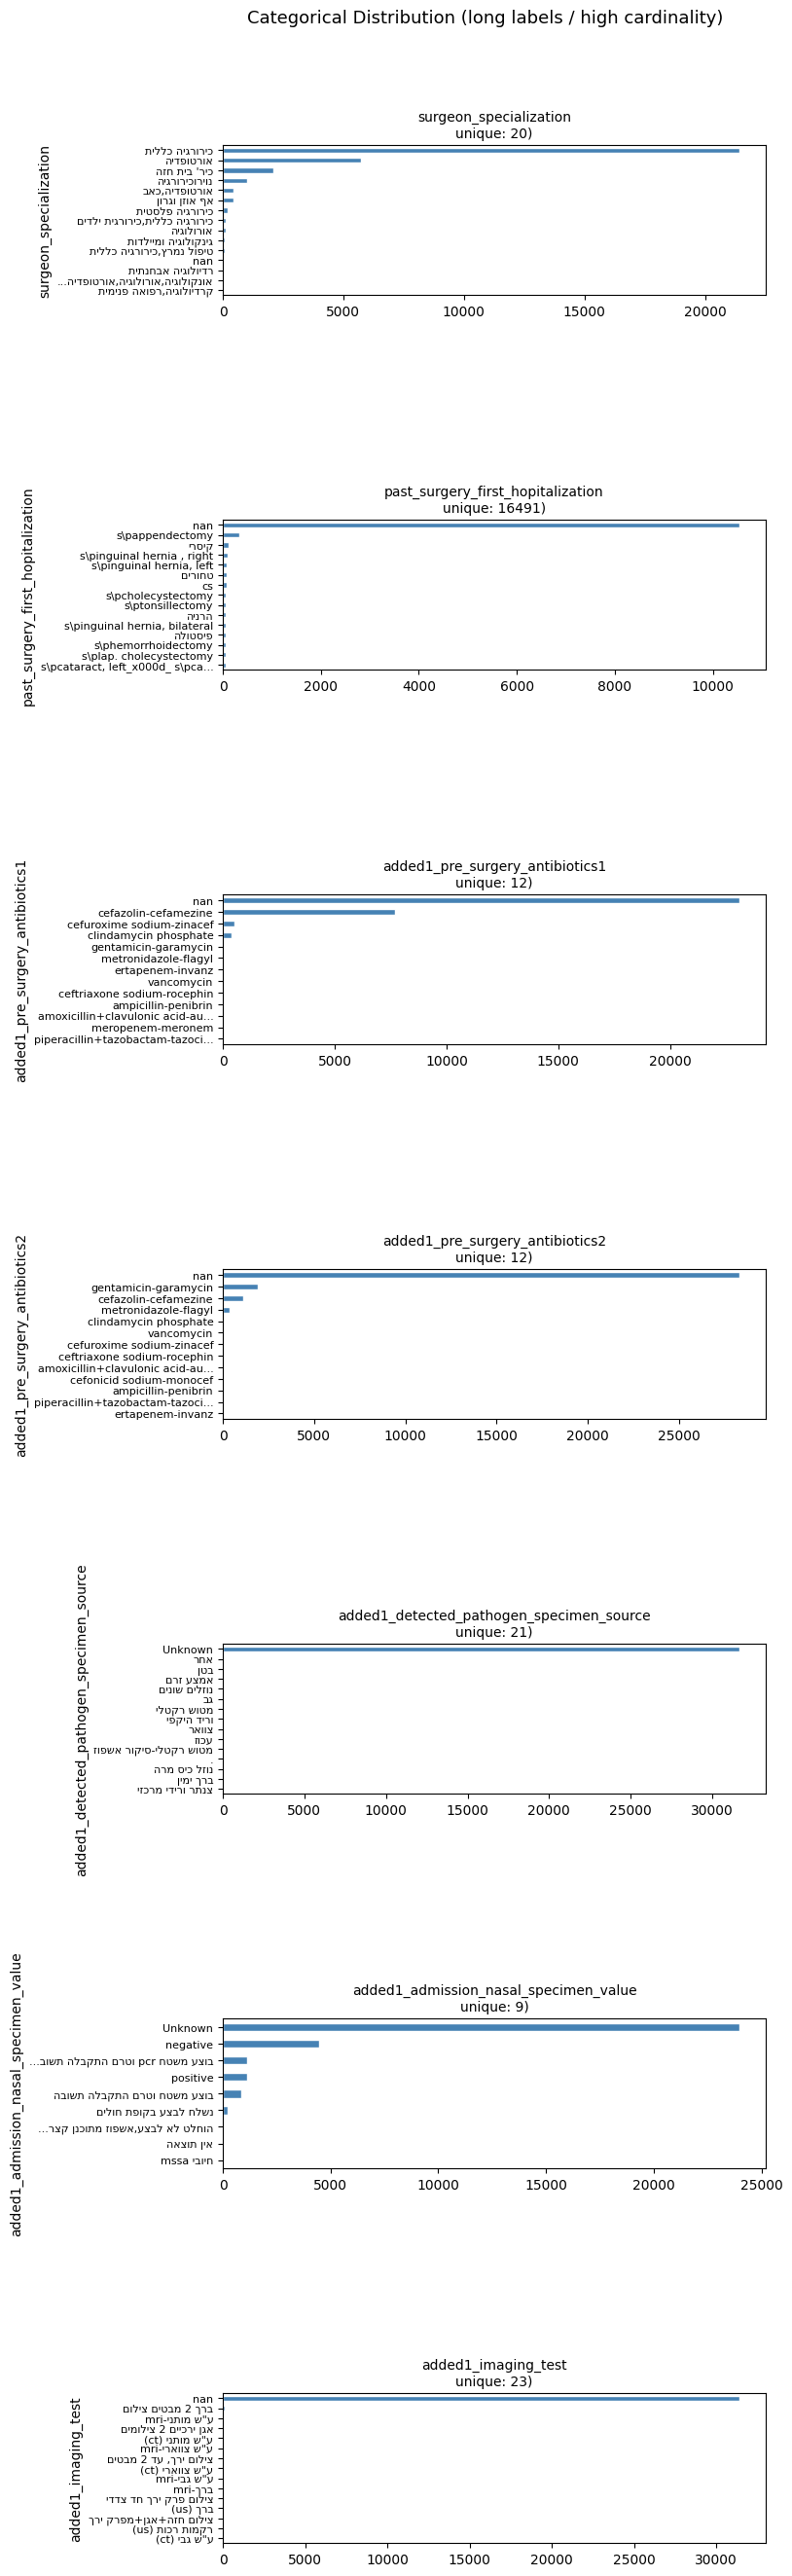

In [23]:
# visualize- bar charts 

long_label_categorical_cols = [
    "surgeon_specialization", 
    "past_surgery_first_hopitalization", 
    "readmission_activity_cluster",
    "readmission_surgeon_specialization",
    "readmission_department",
    "added1_pre_surgery_antibiotics1",
    "added1_pre_surgery_antibiotics2",  
    "added1_detected_pathogen_specimen_source", 
    "added1_admission_nasal_specimen_value", 
    "added1_imaging_test", 
    "added1_infection_diagnosis"
]


standart_categorical_cols = [col for col in categorical_cols
                             if col not in long_label_categorical_cols]

plot_bar_grid(df, standart_categorical_cols, 
              title="Categorical Distributions", n_cols=min(3, len(standart_categorical_cols)), col_w=4)


existing_long_label_cols = [col for col in long_label_categorical_cols
                            if col in df.columns]

plot_bar_grid(df, existing_long_label_cols, title="Categorical Distribution (long labels / high cardinality)", 
              n_cols=1, col_w=6, orientation="horizontal")


### 3- Univariate Analysis

In [24]:
# ------------------------------------------------------------------
# BIVARIATE CONFIGURATION
# ------------------------------------------------------------------

TARGET_COL = "target_binary"

TEXT_TOP_N = 20
MIN_CATEGORY_COUNT = 10
SHAPIRO_MAX_N = 500


# ------------------------------------------------------------------
# SHARED STATISTICAL HELPERS
# ------------------------------------------------------------------

def apply_fdr_bh(result, p_col="p_value"):
    """
    INFO:
    Apply Benjamini-Hochberg FDR correction after testing multiple variables.
    This reduces false-positive findings caused by running many statistical tests.
    """
    if result.empty or p_col not in result.columns:
        return result

    result = result.sort_values(p_col).reset_index(drop=True)
    n = len(result)
    ranks = np.arange(1, n + 1)

    adjusted = result[p_col].to_numpy() * n / ranks
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]

    result["fdr_bh_p_value"] = np.clip(adjusted, 0, 1)
    result["significant_fdr_0.05"] = result["fdr_bh_p_value"] < 0.05

    return result

def _non_empty_or_positive_indicator(series, positive_values=None):
    """
    INFO:
    Convert a column into a 0/1 "positive" indicator.
    - If positive values is None: treate any non-empty, non-missing values as positive
    (same convention as create_binary_target) - use this for raw text diagnosis columns.
    - If positive_values is given: treat membership in that list as positive, comparing
    values as is - use this for an already binary column (e.g. positive_values=[1]),
    so that 0 is correctly treated as negative and not as "non-empty".
    """
    if positive_values is not None:
        return series.isin(positive_values).astype(int)

    cleaned = series.fillna("").astype(str).str.strip()
    return cleaned.ne("").astype(int)


def categorical_association_test(contingency):
    """
    INFO:
    Test association between two categorical variables.

    Statistical methods:
    - Chi-Square is used when expected cell counts are adequate.
    - Fisher's exact test replaces Chi-Square only for sparse 2x2 tables.
    - Cramer's V reports association strength, because a p-value alone does not
      indicate whether the relationship is weak or strong.
    """
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return None

    chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
    sparse = (expected < 5)
    sparse_percent = sparse.mean() * 100

    if contingency.shape == (2, 2) and sparse.any():
        statistic, p_value = stats.fisher_exact(contingency.to_numpy())
        test_name = "Fisher exact"
    else:
        statistic, p_value = chi2, chi_p
        test_name = "Chi-Square"

    n = contingency.to_numpy().sum()
    min_dimension = min(contingency.shape) - 1
    cramers_v = (
        np.sqrt(chi2 / (n * min_dimension))
        if n > 0 and min_dimension > 0
        else np.nan
    )

    return {
        "test": test_name,
        "statistic": statistic,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "minimum_expected_count": expected.min(),
        "expected_cells_below_5_percent": sparse_percent,
        "expected_count_warning": sparse_percent > 20,
    }


def compare_numeric_groups(group_0, group_1):
    """
    INFO:
    Compare one numeric variable between target groups.

    Statistical methods:
    - For samples with n>= SHAPIRO_MAX_N in both groups: Shapiro-wilk checks approximate normality,
    then Welch's t-test (if both look normal) or Mann-Whitney U (if not) is used.
    - Foer samples with n > SHAPIRO_MAX_N in either group: Shapiro-wilk is skiped, since with large samples
    it flags evem trivial deviations from normality as singnificant and stops being informative.
    Mann-Whitney U is used directly - it remains valid regardless of distribution shape.
    """
    group_0 = pd.to_numeric(group_0, errors="coerce").dropna()
    group_1 = pd.to_numeric(group_1, errors="coerce").dropna()

    if len(group_0) < 10 or len(group_1) < 10:
        return None

    if len(group_0) <= SHAPIRO_MAX_N and len(group_1) <= SHAPIRO_MAX_N:
        normal_0 = stats.shapiro(group_0).pvalue > 0.05
        normal_1 = stats.shapiro(group_1).pvalue > 0.05
    else:
        normal_0 = normal_1 = False


    if normal_0 and normal_1:
        statistic, p_value = stats.ttest_ind(
            group_0,
            group_1,
            equal_var=False,
            nan_policy="omit",
        )
        test_name = "Welch t-test"
    else:
        statistic, p_value = stats.mannwhitneyu(
            group_0,
            group_1,
            alternative="two-sided",
        )
        test_name = "Mann-Whitney U"

    n0, n1 = len(group_0), len(group_1)
    if test_name == "Welch t-test":
        pooled_std = np.sqrt((group_0.var(ddof=1) + group_1.var(ddof=1)) / 2)
        effect_size = (group_1.mean() - group_0.mean()) / pooled_std if pooled_std > 0 else np.nan
        effect_size_name = "Cohen's d"
    else:
        effect_size = 1-(2 * statistic) / (n0 * n1)
        effect_size_name = "rank-biserial r"

    return {
        "test": test_name,
        "group_0_n": n0,
        "group_1_n": n1,
        "group_0_mean": group_0.mean(),
        "group_1_mean": group_1.mean(),
        "group_0_median": group_0.median(),
        "group_1_median": group_1.median(),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size_name": effect_size_name,
        "effect_size": effect_size
    }


# ------------------------------------------------------------------
# TARGET CREATION
# ------------------------------------------------------------------

def create_binary_target(df, infection_cols, target_col):
    """
    INFO:
    Create the postoperative infection target according to the clinical definition.

    0 = Both diagnosis columns are missing or empty.
    1 = At least one diagnosis column contains a value.

    This is a target-definition step, not a statistical test.
    """
    missing_cols = [col for col in infection_cols if col not in df.columns]

    if missing_cols:
        raise KeyError(f"Missing infection diagnosis columns: {missing_cols}")

    has_content = (
        df[infection_cols]
        .fillna("")
        .astype(str)
        .apply(lambda col: col.str.strip().ne(""))
    )

    result = df.copy()
    result[target_col] = has_content.any(axis=1).astype(int)

    return result


def plot_target_balance(df, target_col):
    """
    INFO:
    Display target counts and percentages to identify possible class imbalance.
    This is descriptive analysis and does not require a statistical test.
    """
    counts = df[target_col].value_counts().sort_index()
    summary = pd.DataFrame({
        "count": counts,
        "percent": (counts / len(df) * 100).round(3),
    })

    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    summary["count"].plot(kind="bar", ax=axes[0], title="Target Counts")
    summary["percent"].plot(kind="bar", ax=axes[1], title="Target Percentages")
    axes[0].set_ylabel("Count")
    axes[1].set_ylabel("Percent")
    plt.tight_layout()
    plt.show()

    return summary


# ------------------------------------------------------------------
# NUMERIC VS TARGET
# ------------------------------------------------------------------

def numeric_vs_target(df, numeric_cols, target_col, max_features=30):
    """
    INFO:
    Compare numeric variables with the binary target.

    Boxplots provide a distribution-based visual comparison.
    The statistical test is selected by compare_numeric_groups():
    Welch's t-test for approximately normal groups, otherwise Mann-Whitney U.
    FDR correction is applied across all tested numeric variables.
    """
    eligible = [
        col for col in numeric_cols
        if col in df.columns and df[col].notna().sum() >= 30
    ]

    rows = []

    for col in eligible:
        test_result = compare_numeric_groups(
            df.loc[df[target_col] == 0, col],
            df.loc[df[target_col] == 1, col],
        )

        if test_result is not None:
            rows.append({"column": col, **test_result})

    result = apply_fdr_bh(pd.DataFrame(rows))
    display(result.head(50))

    for start in range(0, len(eligible), 12):
        batch = eligible[start:start + 12]
        fig, axes = make_grid(len(batch), n_cols=3, col_w=5, row_h=4)

        for i, col in enumerate(batch):
            plot_df = df[[target_col, col]].copy()
            plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
            sns.boxplot(data=plot_df.dropna(), x=target_col, y=col, ax=axes[i])
            axes[i].set_title(col, fontsize=9)

        hide_unused(axes, len(batch) - 1)
        fig.suptitle("Numeric Features vs Infection Target", fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    return result


# ------------------------------------------------------------------
# CATEGORICAL AND BOOLEAN VS TARGET
# ------------------------------------------------------------------

def categorical_vs_target(
    df,
    categorical_cols,
    target_col,
    max_categories=20,
    min_category_count=10,
    title="Categorical",
):
    """
    INFO:
    Compare categorical variables with the binary target.

    Rare categories are grouped as 'Other' to reduce sparse contingency tables.
    Chi-Square tests association with the target. Fisher's exact test is used
    only for sparse 2x2 tables. Cramer's V measures association strength.
    FDR correction is applied across all tested variables.
    """
    rows = []
    plot_tables = []

    for col in categorical_cols:
        if col not in df.columns:
            continue

        values = df[col].fillna("Missing").astype(str).str.strip()
        values = values.replace("", "Missing")

        counts = values.value_counts()
        frequent = counts[counts >= min_category_count].index[:max_categories]
        grouped = values.where(values.isin(frequent), "Other")

        if grouped.nunique() < 2:
            continue

        contingency = pd.crosstab(grouped, df[target_col])
        test_result = categorical_association_test(contingency)

        if test_result is None:
            continue

        rows.append({
            "column": col,
            "categories_after_grouping": grouped.nunique(),
            **test_result,
        })

        plot_tables.append((
            col,
            pd.crosstab(grouped, df[target_col], normalize="index") * 100,
        ))

    result = apply_fdr_bh(pd.DataFrame(rows))
    display(result.head(100))

    for start in range(0, len(plot_tables), 9):
        batch = plot_tables[start:start + 9]
        fig, axes = make_grid(len(batch), n_cols=3, col_w=7, row_h=4)

        for i, (col, table) in enumerate(batch):
            table.plot(kind="bar", stacked=True, ax=axes[i])
            axes[i].set_title(col, fontsize=8)
            axes[i].set_ylabel("Percent within category")

            short_labels = [(str(label)[:15]+"...") if len(str(label)) > 15 else str(label)
                            for label in table.index]
            

            axes[i].set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
            axes[i].legend(fontsize=7)

        hide_unused(axes, len(batch) - 1)
        fig.suptitle(f"{title} Features vs Infection Target", fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    return result


# ------------------------------------------------------------------
# MISSINGNESS VS TARGET
# ------------------------------------------------------------------

def missingness_vs_target(df, target_col, exclude_cols=None):
    """
    INFO:
    Test whether Missing/Not Missing status is associated with the target.

    Missingness is converted into a binary categorical variable. The same shared
    Chi-Square/Fisher logic is used, with Cramer's V and FDR correction.
    This identifies documentation patterns and does not establish causality.
    """
    excluded = set(exclude_cols or [])
    rows = []

    for col in df.columns:
        if col == target_col or col in excluded:
            continue

        indicator = df[col].isna().map({False: "Not Missing", True: "Missing"})

        if indicator.nunique() < 2:
            continue

        contingency = pd.crosstab(indicator, df[target_col])
        test_result = categorical_association_test(contingency)

        if test_result is None:
            continue

        rows.append({
            "column": col,
            "target_0_missing_percent": (
                df.loc[df[target_col] == 0, col].isna().mean() * 100
            ),
            "target_1_missing_percent": (
                df.loc[df[target_col] == 1, col].isna().mean() * 100
            ),
            **test_result,
        })

    result = apply_fdr_bh(pd.DataFrame(rows))
    display(result.head(100))

    return result


### 4- Multivariate Analysis

In [25]:
# ------------------------------------------------------------------
# MULTIVARIATE HELPER FUNCTIONS
# ------------------------------------------------------------------

def correlation_analysis(df, numeric_cols, target_col, min_non_missing=50, max_columns=40, strong_threshold=0.80,):
    """
    INFO:
    Analyze relationships among numeric variables and with the binary target.

    Statistical methods:
    - Pearson correlation measures linear relationships.
    - Spearman correlation measures monotonic relationships and is more robust
      to skewness and outliers, so it is emphasized for medical EDA.
    - Point-biserial correlation measures the linear association between a
      numeric variable and a binary target.
    - FDR correction is applied to target-correlation p-values.

    Strong feature-feature correlations may indicate redundant information or
    multicollinearity, but they do not prove causation.
    """
    eligible = [
        col for col in numeric_cols
        if col in df.columns and df[col].notna().sum() >= min_non_missing
    ]

    if not eligible:
        print("No eligible numeric columns for correlation analysis.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # Limit very wide heatmaps using the highest-variance eligible columns.
    variances = df[eligible].apply(
        lambda col: pd.to_numeric(col, errors="coerce").var()
    )
    selected = variances.sort_values(ascending=False).head(max_columns).index

    numeric_df = df[selected].apply(pd.to_numeric, errors="coerce")
    pearson_corr = numeric_df.corr(method="pearson")
    spearman_corr = numeric_df.corr(method="spearman")

    for name, corr in {
        "Pearson": pearson_corr,
        "Spearman": spearman_corr,
    }.items():
        plt.figure(figsize=(
            max(12, len(selected) * 0.45),
            max(10, len(selected) * 0.45),
        ))
        sns.heatmap(
            corr,
            center=0,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={"shrink": 0.7},
        )
        plt.title(f"{name} Correlation Matrix")
        plt.tight_layout()
        plt.show()

    upper = spearman_corr.where(
        np.triu(np.ones(spearman_corr.shape), k=1).astype(bool)
    )

    strong_pairs = (
        upper.stack()
        .rename("spearman_correlation")
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
        })
    )
    strong_pairs["absolute_correlation"] = (
        strong_pairs["spearman_correlation"].abs()
    )
    strong_pairs = strong_pairs.loc[
        strong_pairs["absolute_correlation"] >= strong_threshold
    ].sort_values("absolute_correlation", ascending=False)

    target_rows = []

    for col in eligible:
        pair = df[[col, target_col]].copy()
        pair[col] = pd.to_numeric(pair[col], errors="coerce")
        pair = pair.dropna()

        if len(pair) < 30 or pair[target_col].nunique() < 2:
            continue

        spearman_r, spearman_p = stats.spearmanr(
            pair[col],
            pair[target_col],
        )
        point_r, point_p = stats.pointbiserialr(
            pair[target_col],
            pair[col],
        )

        target_rows.append({
            "column": col,
            "n": len(pair),
            "spearman_r": spearman_r,
            "p_value": spearman_p,
            "point_biserial_r": point_r,
            "point_biserial_p_value": point_p,
        })

    target_corr = apply_fdr_bh(pd.DataFrame(target_rows))

    if not target_corr.empty:
        target_corr["absolute_spearman"] = target_corr["spearman_r"].abs()
        target_corr = target_corr.sort_values(
            "absolute_spearman",
            ascending=False,
        )

        top = target_corr.head(20).sort_values("spearman_r")
        plt.figure(figsize=(10, 8))
        plt.barh(top["column"], top["spearman_r"])
        plt.axvline(0, linewidth=1)
        plt.xlabel("Spearman correlation with infection target")
        plt.ylabel("Feature")
        plt.title("Top Numeric Correlations with Infection Target")
        plt.tight_layout()
        plt.show()

    print("Strong feature-feature correlations:")
    display(strong_pairs.head(100))

    print("Numeric correlations with target:")
    display(target_corr.head(100))

    return pearson_corr, spearman_corr, strong_pairs, target_corr


def categorical_correlation_analysis(df, 
                                     categorical_cols, 
                                     min_non_missing=50, 
                                     max_columns=30, 
                                     strong_threshold=0.80,
                                     min_category_count=None):
    """
    INFO:
    Analyze relationships among categorical/boolean variables themselves (not against the target),
    using Cramer' V.

    Statistical methods:
    - For every pair of columns, values are grouped ("Missing" for nulls,
    rare categories below min_category_count merged into "Other") and compared using
    the same Chi-square/Fisher logic already used for feature-vs-target tests, reporting 
    Cramer's V as the association strength.

    Strong feature-feature associations may indicate redundant information,
    but they do not prove causation, and require review before being acted on.
    """
    if min_category_count is None:
        min_category_count = MIN_CATEGORY_COUNT

    eligible = [
        col for col in categorical_cols
        if col in df.columns and df[col].notna().sum() >= min_non_missing
    ]

    if len(eligible) < 2:
        print("No enough eligible categorical columns for correlation analysis.")
        return pd.DataFrame(), pd.DataFrame()

    if len(eligible) > max_columns:
        missing_rate = df[eligible].isna().mean().sort_values()
        eligible = missing_rate.head(max_columns).index.tolist()

    def _grouped(col):
        values = df[col].fillna("Missing").astype(str).str.strip()
        values = values.replace("", "Missing")
        counts = values.value_counts()
        frequent = counts[counts >= min_category_count].index
        return values.where(values.isin(frequent) | values.eq("Missing"), "Other")

    grouped_cols = {col: _grouped(col) for col in eligible}

    cramers_matrix = pd.DataFrame(np.eye(len(eligible)), index=eligible, columns=eligible)
    pair_rows = []

    for i, col_1 in enumerate(eligible):
        for col_2 in eligible[i + 1:]:
            contingency = pd.crosstab(grouped_cols[col_1], grouped_cols[col_2])
            test_result = categorical_association_test(contingency)
            if test_result is None:
                continue

            cramers_v = test_result["cramers_v"]
            cramers_matrix.loc[col_1, col_2] = cramers_v
            cramers_matrix.loc[col_2, col_1] = cramers_v

            pair_rows.append({
                "feature_1": col_1,
                "feature_2": col_2,
                "cramers_v": cramers_v,
            })

    plt.figure(figsize=(max(12, len(eligible) * 0.45), max(10, len(eligible) * 0.45)))
    sns.heatmap(
        cramers_matrix, 
        vmin=0,
        vmax=1,
        cmap = "coolwarm",
        square=True,
        cbar_kws={"shrink":0.7}   
    )
    plt.title("Categorical association matrix (Cramer's V)")
    plt.tight_layout()
    plt.show()

    strong_categorical_pairs = (
        pd.DataFrame(pair_rows)
        .loc[lambda d: d["cramers_v"] >= strong_threshold]
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )

    print("Strong feature-feature categorical associations:")
    display(strong_categorical_pairs.head(100))

    return cramers_matrix, strong_categorical_pairs


def select_pairplot_candidates(target_corr, leakage_keywords, max_variables=6):
    """
    INFO:
    Select numeric variables for the clinical pairplot.
    Selection rules:
    - Rank numeric features by absolute spearman correlation with the target
    - Skip any features whose name matches to one of leakage_keywords.
    """

    if target_corr.empty:
        return []

    ranked = target_corr.loc[
        ~target_corr["column"].apply(
            lambda col: any(keyword in col.lower() for keyword in leakage_keywords)
        )
    ]
    ranked = ranked.sort_values("absolute_spearman", ascending=False)

    return ranked["column"].head(max_variables).tolist()


def plot_clinical_pairplot(
    df,
    candidate_cols,
    target_col,
    max_variables=6,
    max_rows=3000,
):
    """
    INFO:
    Display joint distributions for a small set of clinically important numeric
    variables. Pairplots are exploratory visualizations and do not replace
    formal statistical tests or multivariable modeling.
    """
    selected = [
        col for col in candidate_cols
        if col in df.columns
    ][:max_variables]

    if len(selected) < 2:
        print("Not enough clinical variables were found for a pairplot.")
        return

    plot_df = df[selected + [target_col]].dropna(subset=[target_col])

    if len(plot_df) > max_rows:
        plot_df = plot_df.sample(max_rows, random_state=42)

    sns.pairplot(
        plot_df,
        vars=selected,
        hue=target_col,
        corner=True,
        plot_kws={"alpha": 0.45, "s": 18},
    )
    plt.show()


def build_feature_review_table(
    df,
    column_groups,
    target_cols,
    leakage_keywords,
):
    """
    INFO:
    Review every candidate feature for semantic type, missingness, cardinality
    and possible target leakage.

    Leakage flags are based on column names and require clinical review; they are
    warnings, not automatic exclusion decisions.
    """
    rows = []

    for col in df.columns:
        if col in target_cols:
            continue

        semantic_type = next(
            (
                group_name
                for group_name, columns in column_groups.items()
                if col in columns
            ),
            "Unmapped",
        )

        unique_values = df[col].nunique(dropna=True)

        rows.append({
            "column": col,
            "semantic_type": semantic_type,
            "missing_percent": df[col].isna().mean() * 100,
            "unique_values": unique_values,
            "zero_variance": unique_values <= 1,
            "potential_leakage": any(
                keyword in col.lower()
                for keyword in leakage_keywords
            ),
        })

    result = pd.DataFrame(rows).sort_values(
        ["potential_leakage", "zero_variance", "missing_percent"],
        ascending=[False, False, False],
    )

    display(result.head(100))
    return result


def summarize_multivariate_findings(
        strong_pairs, 
        strong_categorical_pairs, 
        feature_review_df,
        target_corr, 
        categorical_tests_df,
        boolean_tests_df,
        high_association_threshold=0.15):
    """
    aggregation into a short summary
    """
    print("="*60)
    print("MULTIVARIATE SUMMARY - input for cleaning/feature selection")
    print("="*60)

    print(f"\nNear-duplicate numeric pairs: {len(strong_pairs)}")
    if not strong_pairs.empty:
        display(strong_pairs)

    print(f"\nNear-duplicate categorical_pairs: {len(strong_categorical_pairs)}")
    if not strong_categorical_pairs.empty:
        display(strong_categorical_pairs)

    zero_variance_cols = feature_review_df.loc[feature_review_df["zero_variance"], "column"].tolist()
    print(f"\nZero variance columns: {len(zero_variance_cols)}")
    if zero_variance_cols:
        print(zero_variance_cols)

    leakage_flagged = feature_review_df.loc[feature_review_df["potential_leakage"], "column"].tolist()
    print(f"\nColumns flagged as potential leakage: {len(leakage_flagged)}")

    strong_numeric = target_corr.loc[
        target_corr["absolute_spearman"] >= high_association_threshold,
        ["column", "absolute_spearman"],
    ].rename(columns={"absolute_spearman": "association_strength"})


    strong_categorical = categorical_tests_df.loc[
        categorical_tests_df["cramers_v"] >= high_association_threshold,
        ["column", "cramers_v"],
    ].rename(columns={"cramers_v": "association_strength"})


    strong_boolean = boolean_tests_df.loc[
        boolean_tests_df["cramers_v"] >= high_association_threshold,
        ["column", "cramers_v"],
    ].rename(columns={"cramers_v": "association_strength"})
        
    strong_association = pd.concat(
        [strong_numeric, strong_categorical, strong_boolean],
        ignore_index=True,
    )

    unflagged_strong = strong_association.loc[
        ~strong_association["column"].isin(leakage_flagged)
    ].sort_values("association_strength", ascending=False)


    print(f"\nStrong target association but not flagged as leakage: {len(unflagged_strong)}")
    if not unflagged_strong.empty:
        display(unflagged_strong)

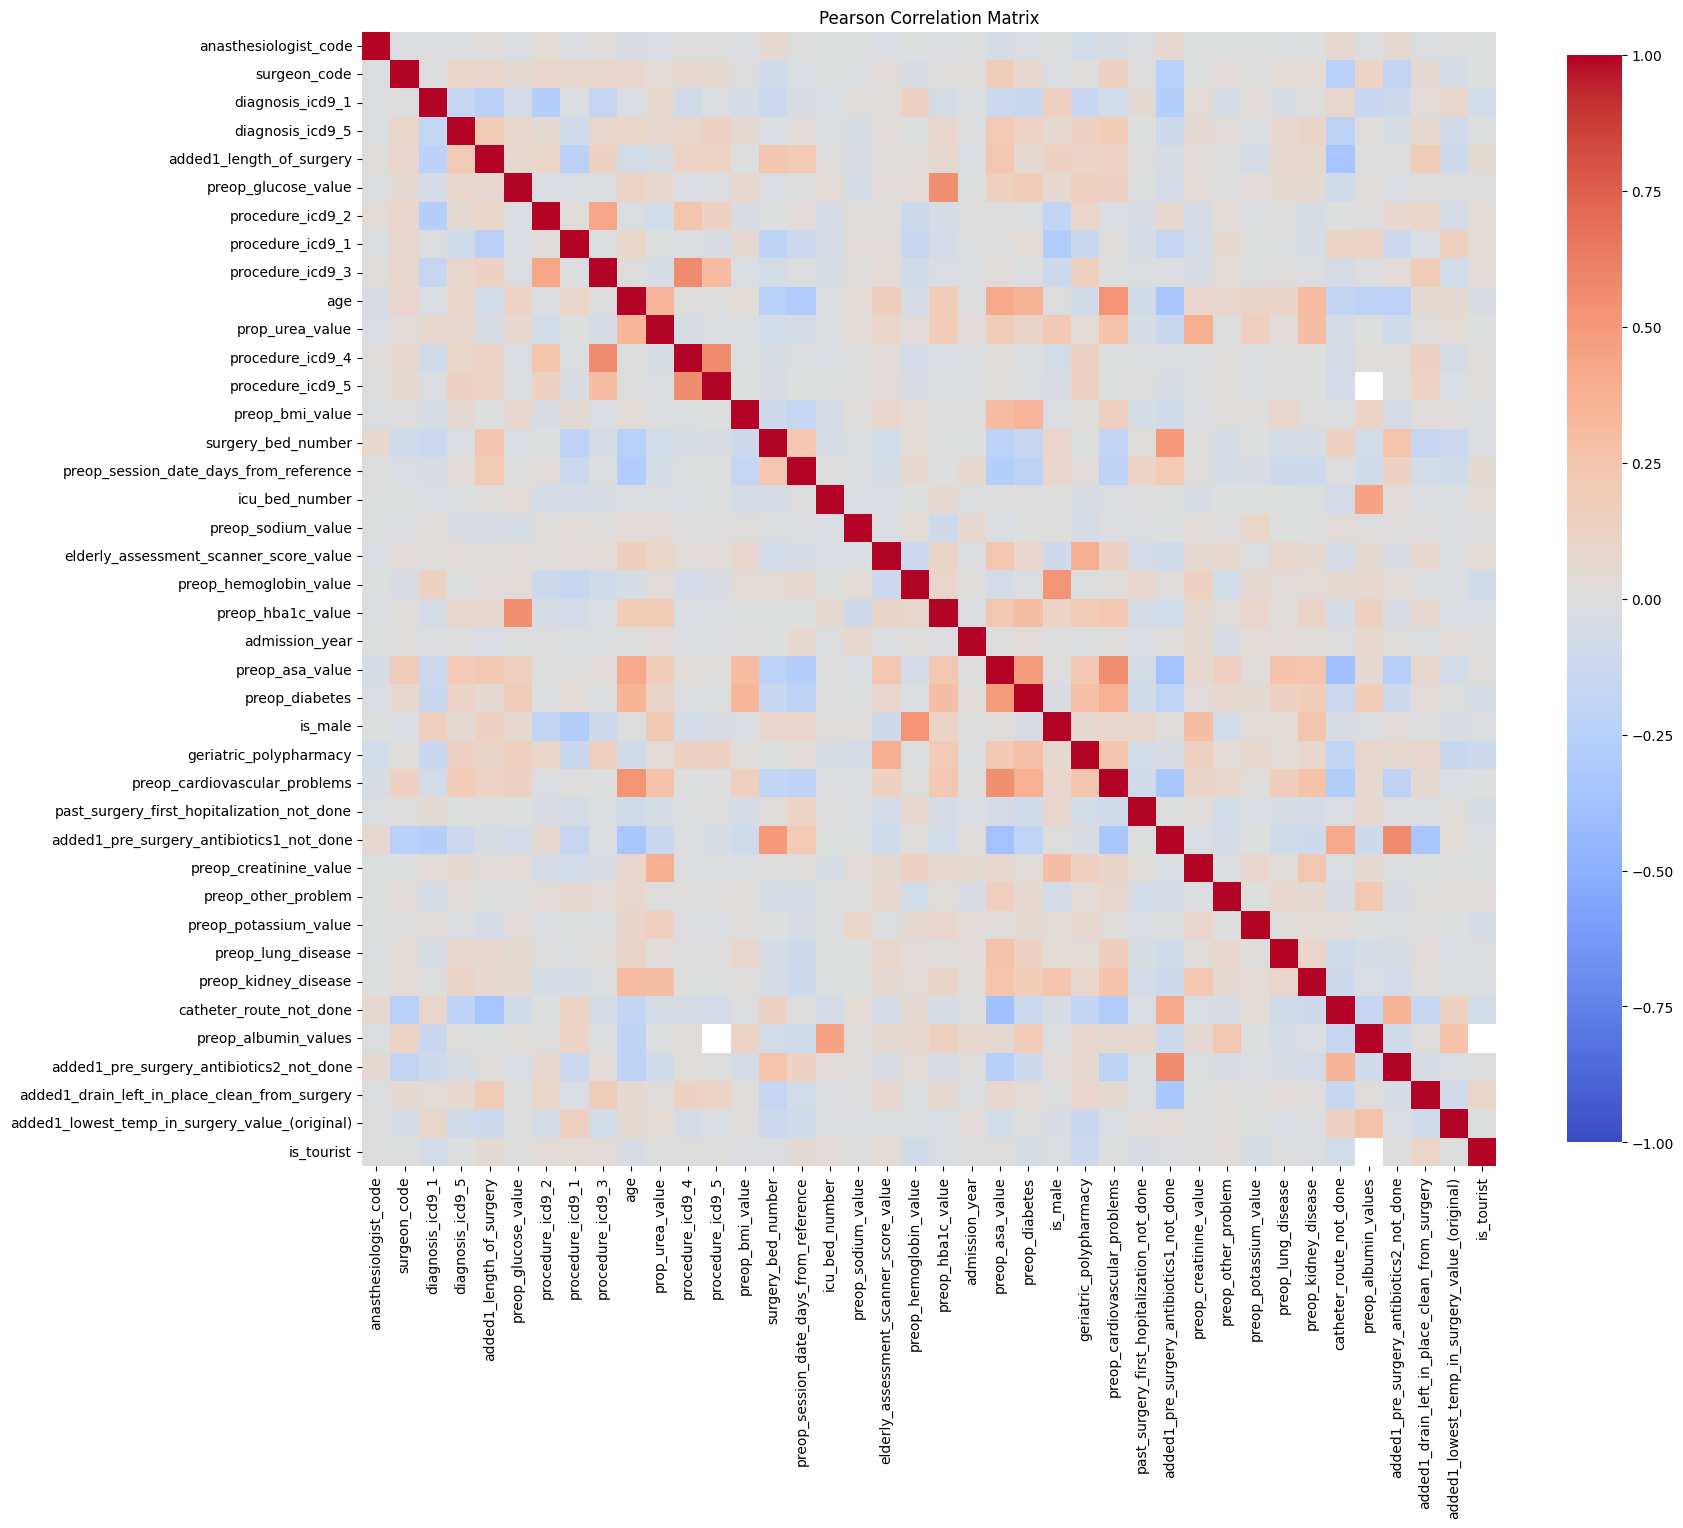

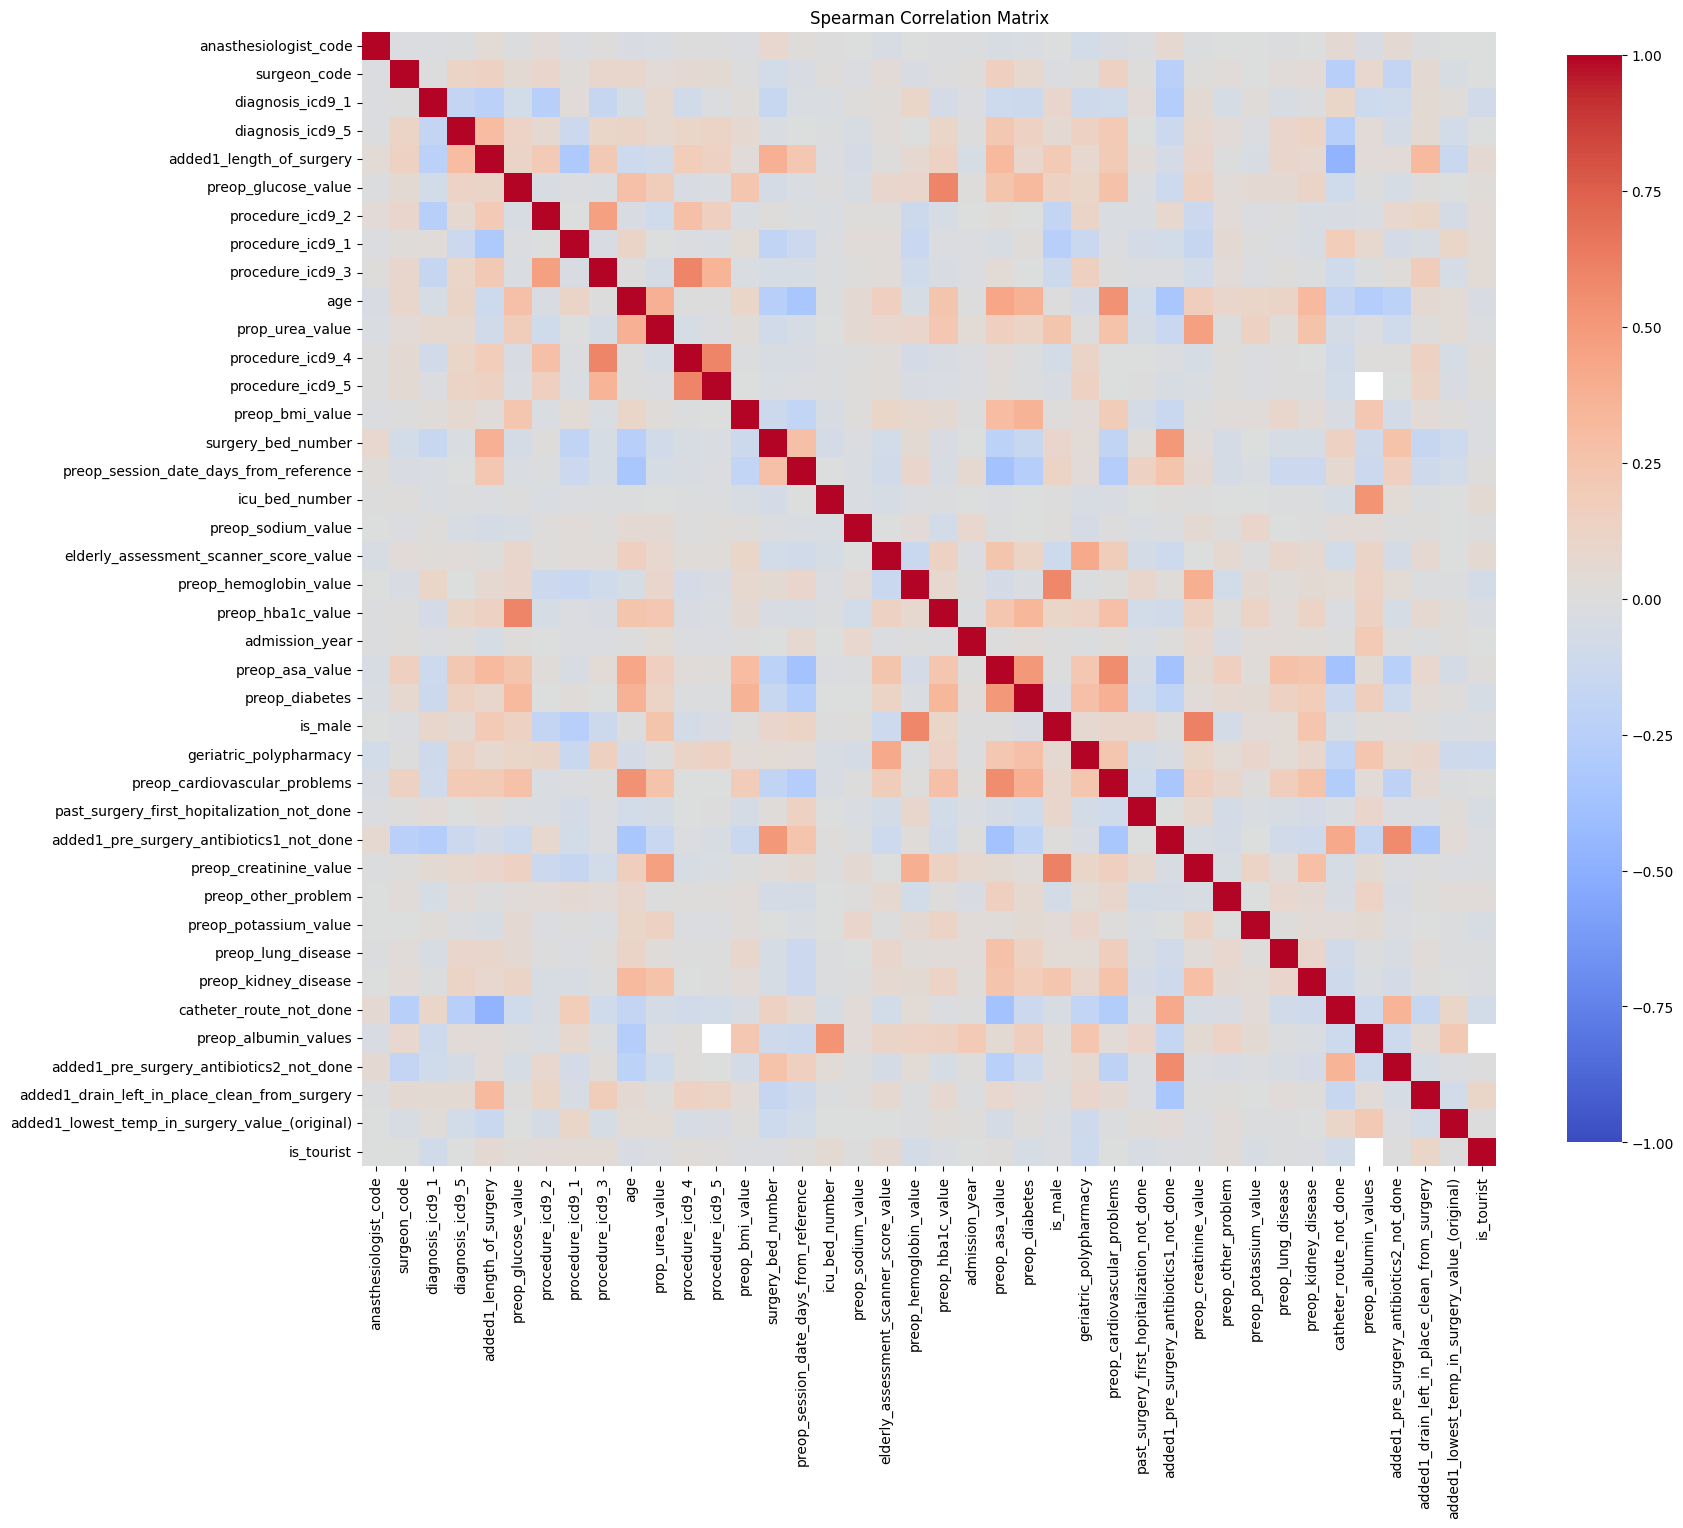

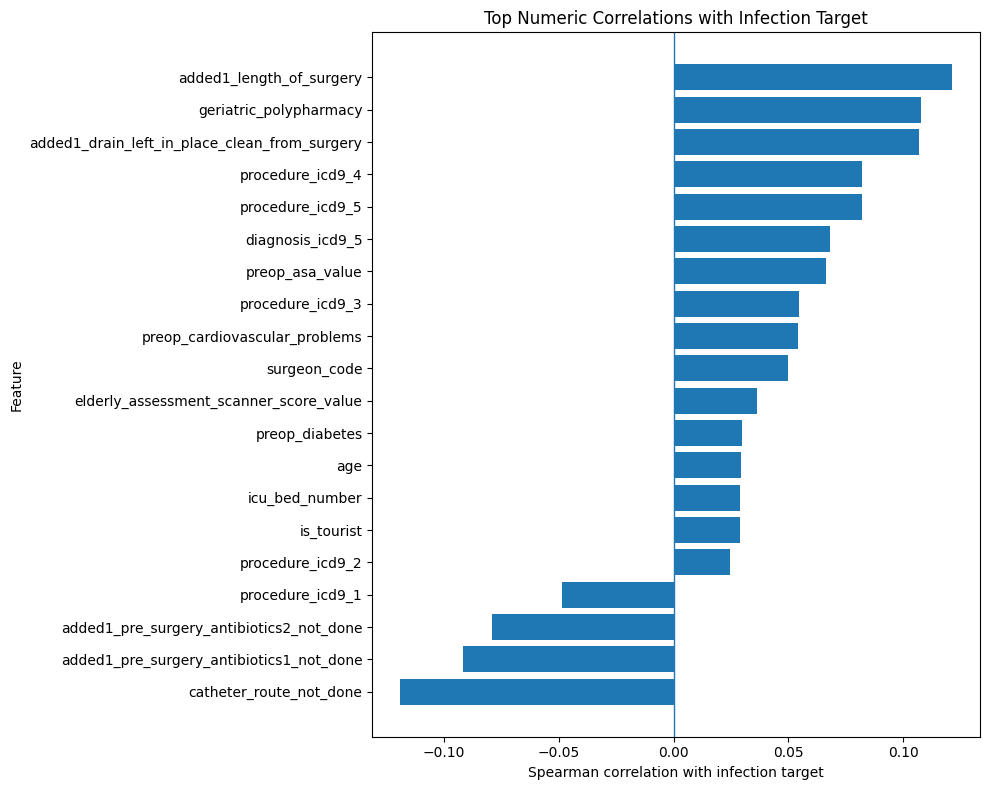

Strong feature-feature correlations:


,feature_1,feature_2,spearman_correlation,absolute_correlation


Numeric correlations with target:


,column,n,spearman_r,p_value,point_biserial_r,point_biserial_p_value,fdr_bh_p_value,significant_fdr_0.05,absolute_spearman
8,added1_length_of_surgery,6981,0.121343,2.582870e-24,0.106366,5.064093e-19,1.147942e-23,True,0.121343
0,catheter_route_not_done,31849,-0.119128,5.367474e-101,-0.119128,5.367474e-101,2.146990e-99,True,0.119128
28,geriatric_polypharmacy,254,0.107688,8.675189e-02,0.107688,8.675189e-02,1.196578e-01,False,0.107688
1,added1_drain_left_in_place_clean_from_surgery,31849,0.106624,3.551997e-81,0.106624,3.551997e-81,7.103994e-80,True,0.106624
2,added1_pre_surgery_antibiotics1_not_done,31849,-0.091570,2.855717e-60,-0.091570,2.855717e-60,3.807623e-59,True,0.091570
3,procedure_icd9_4,31849,0.082164,7.750461e-49,0.072764,1.186299e-38,7.014803e-48,True,0.082164
4,procedure_icd9_5,31849,0.082118,8.768503e-49,0.080109,1.665189e-46,7.014803e-48,True,0.082118
5,added1_pre_surgery_antibiotics2_not_done,31849,-0.078999,2.865981e-45,-0.078999,2.865981e-45,1.910654e-44,True,0.078999
6,diagnosis_icd9_5,31849,0.067954,6.424005e-34,0.062640,4.589100e-29,3.670860e-33,True,0.067954
7,preop_asa_value,27734,0.066226,2.436088e-28,0.068453,3.614487e-30,1.218044e-27,True,0.066226


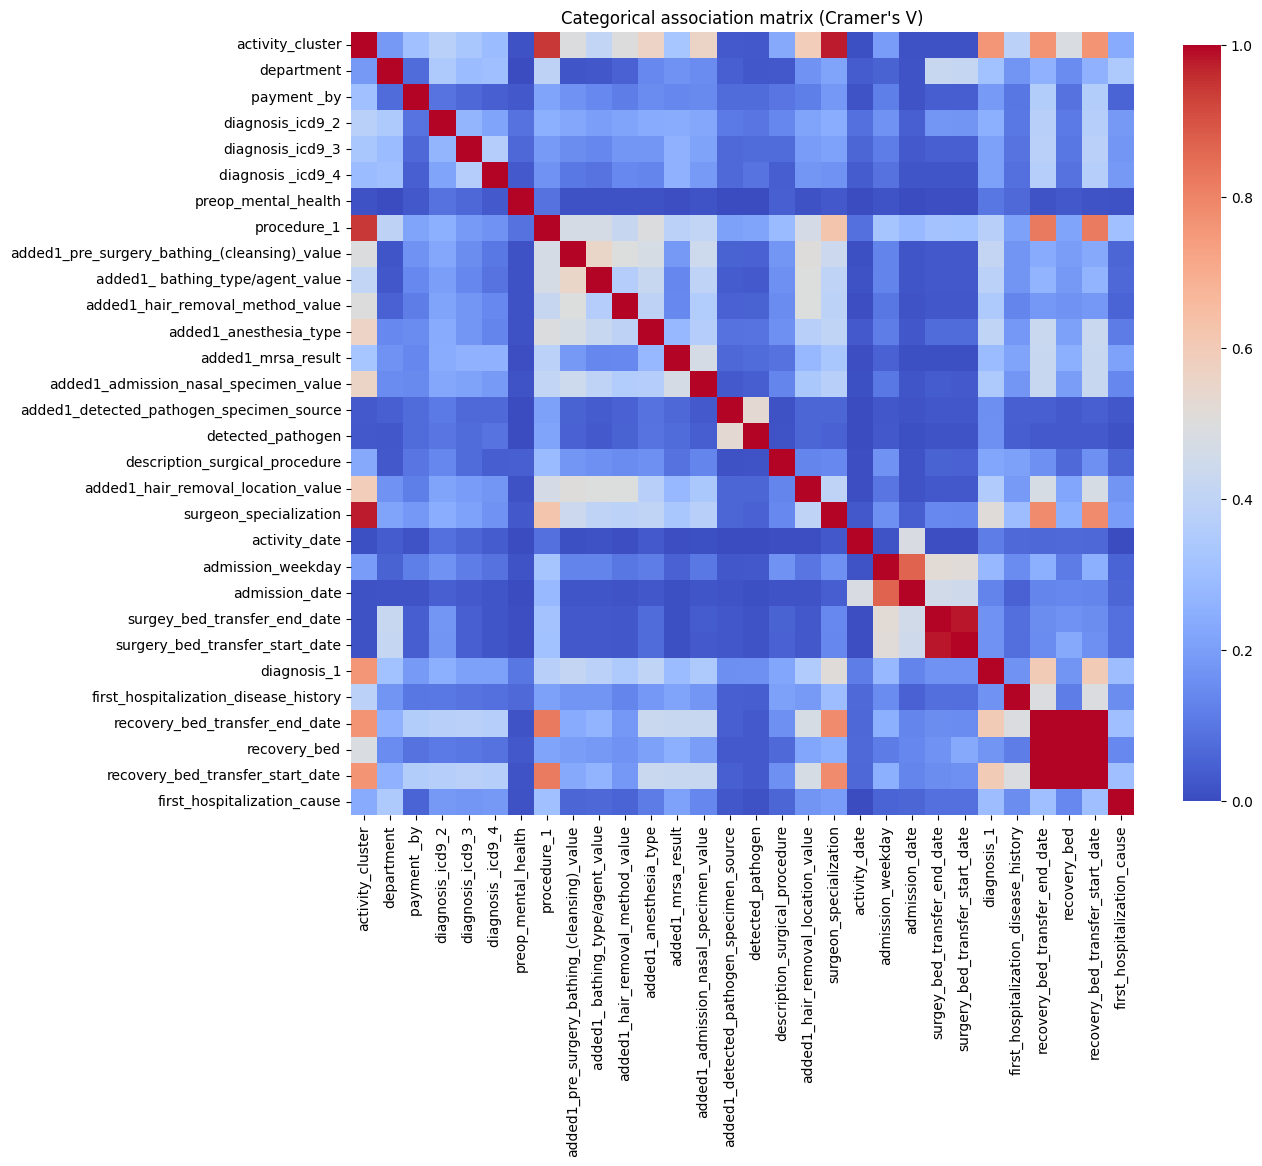

Strong feature-feature categorical associations:


,feature_1,feature_2,cramers_v
0,recovery_bed_transfer_end_date,recovery_bed,0.999674
1,recovery_bed,recovery_bed_transfer_start_date,0.999174
2,recovery_bed_transfer_end_date,recovery_bed_transfer_start_date,0.998535
3,surgey_bed_transfer_end_date,surgery_bed_transfer_start_date,0.982923
4,activity_cluster,surgeon_specialization,0.979503
5,activity_cluster,procedure_1,0.944840
6,admission_weekday,admission_date,0.867791
7,procedure_1,recovery_bed_transfer_end_date,0.820829
8,procedure_1,recovery_bed_transfer_start_date,0.820128


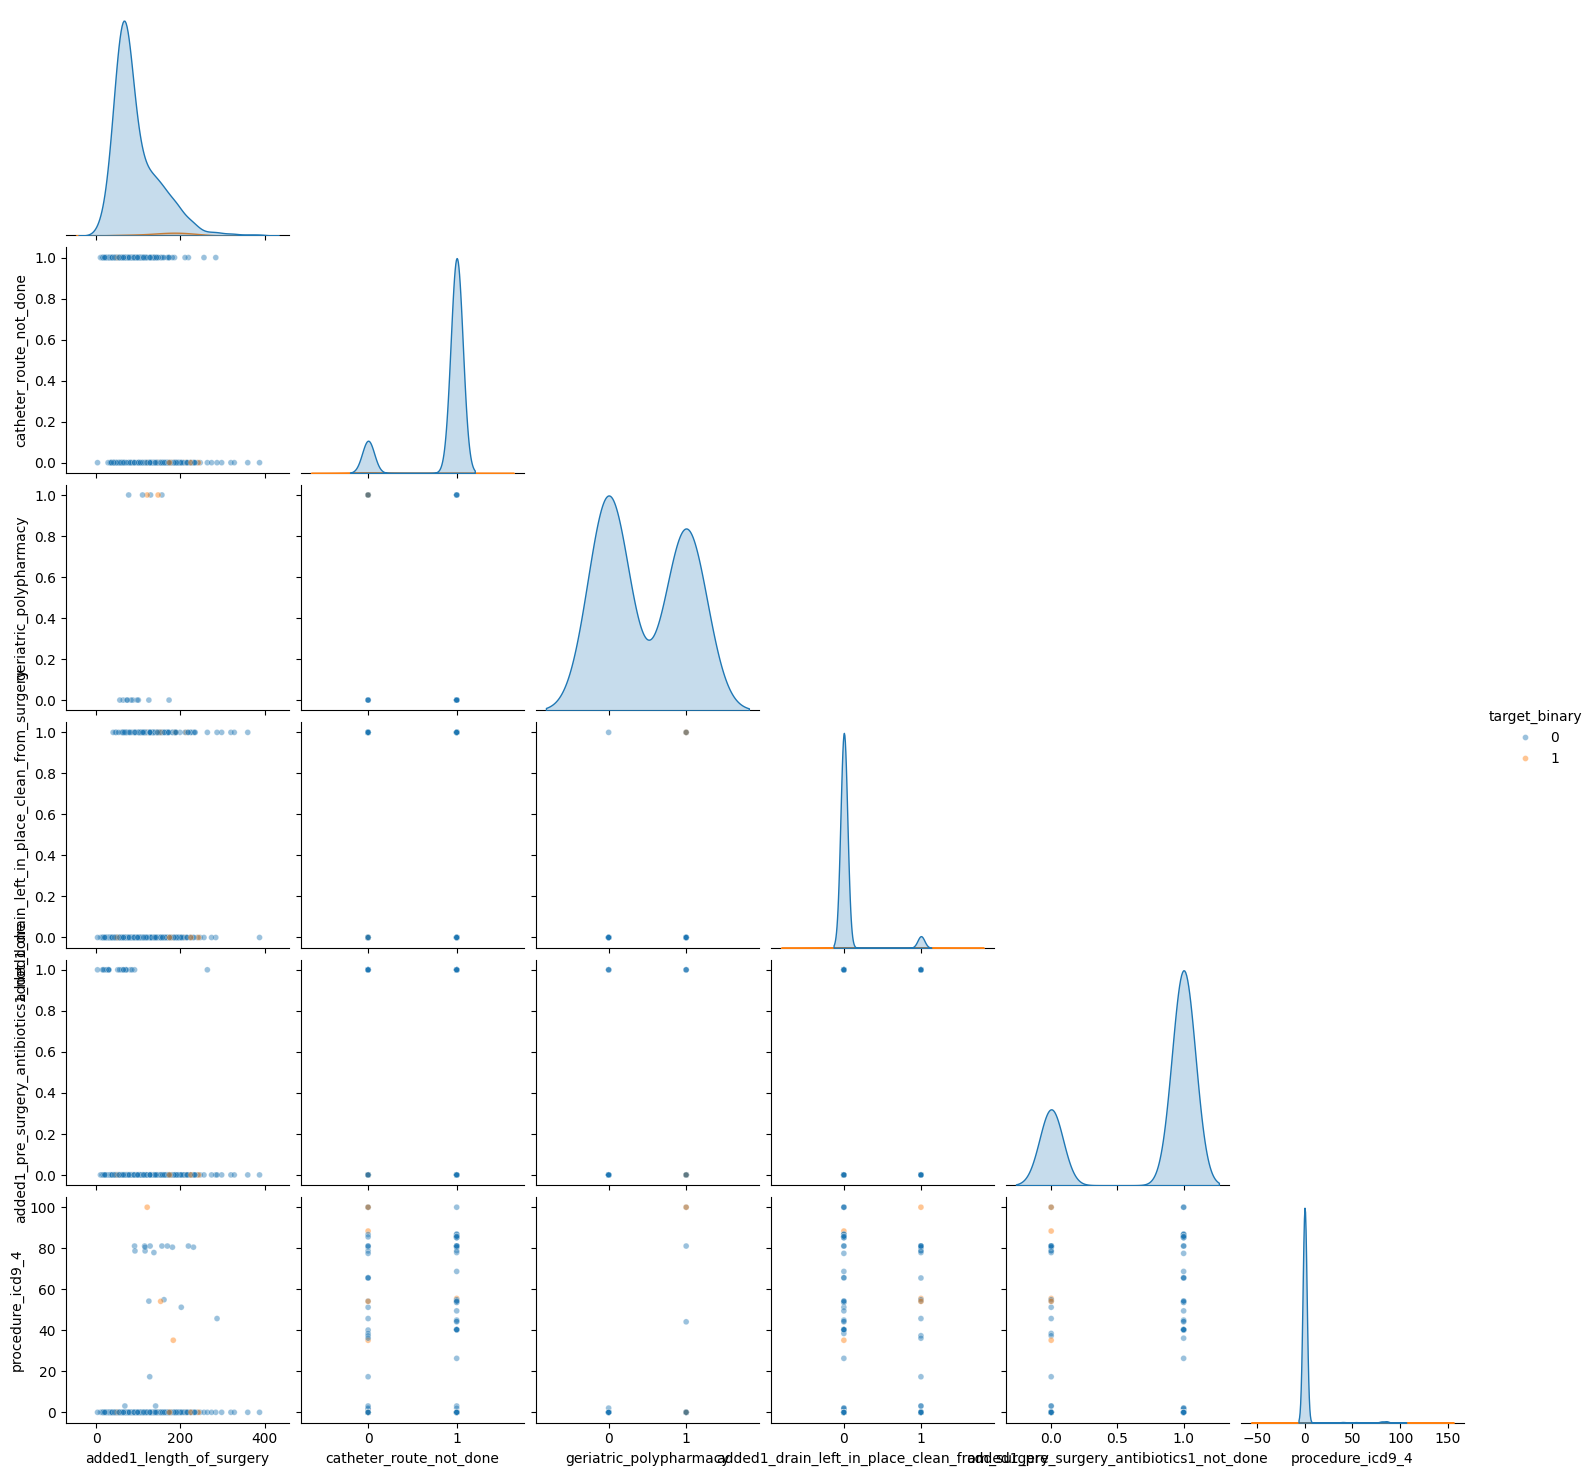

In [26]:
# ------------------------------------------------------------------
# RUN MULTIVARIATE ANALYSIS
# ------------------------------------------------------------------

(
    pearson_corr,
    spearman_corr,
    high_corr_pairs,
    target_corr_df,
) = correlation_analysis(
    df,
    numeric_cols=numeric_cols,
    target_col=TARGET_COL,
    min_non_missing=50,
    max_columns=40,
    strong_threshold=0.80,
)

existing_categorical_like_cols = categorical_cols 

cramers_matrix, strong_categorical_pairs = categorical_correlation_analysis(
    df, categorical_cols = existing_categorical_like_cols, min_non_missing=50, max_columns=30, strong_threshold=0.80,)


# Review possible leakage and general feature quality.
leakage_keywords = [
    "discharge",
    "readmission",
    "infection_diagnosis",
    "ssi_diagnosis",
    "culture_result",
    "organism_detected",
    "wound_culture",
    "after_36_hours",
    "within_100_days",
]

# Pairplot only for a small clinically selected set.
clinical_pairplot_candidates = select_pairplot_candidates(target_corr_df, leakage_keywords, max_variables=6)

plot_clinical_pairplot(
    df,
    candidate_cols=clinical_pairplot_candidates,
    target_col=TARGET_COL,
)



